In [1]:
import fsps
sp = fsps.StellarPopulation(imf_type=1, sfh=4, tau=2,
                            dust_type=2, dust2=0.2,
                            zcontinuous=True, logzsol=0, 
                            add_neb_emission=True, add_igm_absorption=True)

In [2]:
import numpy as np
import astropy.units as u
import astropy.constants as c
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FixedLocator
from matplotlib.gridspec import GridSpec

# plt.rcParams['text.usetex'] = True
# plt.rcParams['font.family'] = 'serif'

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

In [4]:
class gal(object):
    def __init__(self, z, age=0.5, mass=10**10.5, zform=None, tau=2, add_neb_emission=False):
        self.z = z
        self.mass = mass
        self.tau = tau
        self.age = age if zform is None else (cosmo.age(z) - cosmo.age(zform)).value
        self.add_neb_emission = add_neb_emission

    def mags(self):
        sp.params['tau'] = self.tau
        sp.params['add_neb_emission'] = self.add_neb_emission
        return redshift_mags(self.z, age=self.age, mass=self.mass)

    def spec(self, velscale=None):
        sp.params['tau'] = self.tau
        sp.params['add_neb_emission'] = self.add_neb_emission
        sp.params['zred'] = self.z
        lam,spec = redshift_spec(self.z, age=self.age, mass=self.mass, velscale=velscale)
        return lam, spec

def redshift_mags(z, filters, age=1, mass=1e11, zform=13):
    if zform is not None:
        tage = (cosmo.age(z) - cosmo.age(zform)).value
    else:
        tage = age

    mags = sp.get_mags(tage=tage, redshift=z, bands=filters)
    mass_scale = mass / sp.stellar_mass
    mags += -2.5*np.log10(mass_scale / (1+z))

    lam = np.array([fsps.filters.get_filter(x).lambda_eff for x in filters])
    lam /= 1e4 # convert to micron

    return lam, mags


def redshift_spec(z, age=1, mass=1e11, zform=None, velscale=None):
    if zform is not None:
        tage = (cosmo.age(z) - cosmo.age(zform)).value
    else:
        tage = age

    lam, spec = sp.get_spectrum(tage=tage)

    if velscale is not None:
        spec = sp.smoothspec(lam, spec, velscale)

    # give spec units
    spec *= u.Lsun / u.Hz

    dL = cosmo.luminosity_distance(z)
    vL = 4*np.pi * dL**2

    mass_scale = mass / sp.stellar_mass

    zlam = (1+z) * lam # redshift
    zlam /= 1e4 # convert to micron

    zspec_Jy = (mass_scale * spec / vL).to(u.Jy).value # / (1+z)
    zspec = -2.5*np.log10(zspec_Jy  * (1+z) / 3631)

    return zlam, zspec

In [5]:
ms = 10**10.

kwargs = dict(zform=12, mass=ms)
#kwargs = dict(age=0.75, mass=ms)

gal3 = gal(3, **kwargs)
gal4 = gal(4, zform=12, mass=10**10.65)
gal5 = gal(5, **kwargs)
gal6 = gal(6, zform=12, mass=10**10.24)
gal7 = gal(7, **kwargs)
gal8 = gal(8, **kwargs)
gal9 = gal(9, **kwargs)
gal10 = gal(10, zform=12, mass=10**9.5)

In [6]:
from scipy.integrate import simpson

def lam_pivot(filt):
    lam, trans = filt.transmission
    T = trans * lam 
    T /= T.max()

    top = simpson(T,lam)
    bottom = simpson(T/lam**2,lam)

    return np.sqrt(top/bottom)

def width_eff(filt):
    lam, trans = filt.transmission
    T = trans * lam 
    T /= T.max()

    return simpson(T,lam)


In [7]:
fields = {
    'H20': dict(
        filters = ['megacam_u', 'hsc_g', 'hsc_r', 'hsc_i', 'hsc_z', 'euclid_y', 'euclid_j', 'euclid_h', 'irac_1', 'irac_2'],
        filter_names = ['u', 'g', 'r', 'i', 'z', 
                        'Y', 'J', 'H', 'IRAC $[3.6\,\mu m]$', 'IRAC $[4.5\,\mu m]$'],
        depths = [26.4, 27.5, 27.5, 27, 26.5, 26.3, 26.5, 26.4, 24.8, 24.7],
    ),
    'EDFS': dict(
        filters = ['lsst_u', 'lsst_g', 'lsst_r', 'lsst_i', 'lsst_z', 'lsst_y', 'euclid_y', 'euclid_j', 'euclid_h', 'irac_1', 'irac_2'],
        filter_names = ['u', 'g', 'r', 'i', 'z', 'y', 
                        r'\textit{Y}$_\mathrm{E}$', r'\textit{J}$_\mathrm{E}$', r'\textit{H}$_\mathrm{E}$', '3.6', '4.5'],
        depths = [26.8, 28.4, 28.5, 28.3, 28.0, 26.8, 
                26.3, 26.5, 26.4, 23.9, 23.8],
    )
}
fields['H20']['lam_effs'] = np.array([lam_pivot(fsps.filters.get_filter(x)) for x in fields['H20']['filters']]) / 1e4
fields['EDFS']['lam_effs'] = np.array([lam_pivot(fsps.filters.get_filter(x)) for x in fields['EDFS']['filters']]) / 1e4

fields['H20']['width'] = np.array([width_eff(fsps.filters.get_filter(x)) for x in fields['H20']['filters']]) / 1e4
fields['EDFS']['width'] = np.array([width_eff(fsps.filters.get_filter(x)) for x in fields['EDFS']['filters']]) / 1e4


In [14]:
print(fields['H20']['width'])

[0.04525322 0.10439143 0.13598032 0.15174845 0.07723856 0.22588138
 0.3685413  0.45944153 0.65140979 0.88270267]


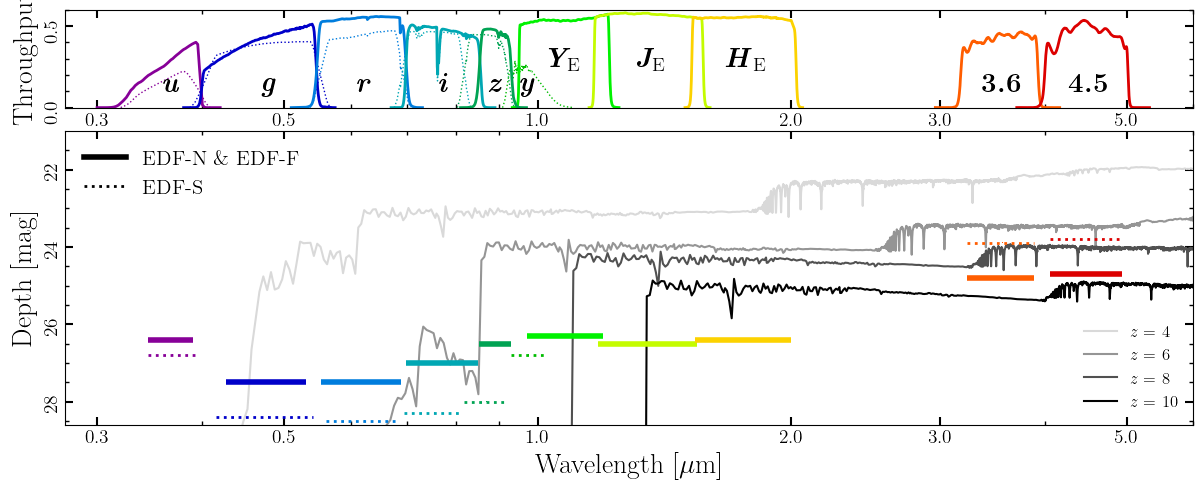

In [17]:
xlims = (0.275,6)
xticks = [0.1,0.2,0.3,0.5,1,2,3,5]

fig = plt.figure(figsize=(12,5))
gs = GridSpec(2,1, height_ratios=[1,3], hspace=0.12, left=0.05, top=0.95, right=0.99, bottom=0.12)

plt.subplot(gs[0])
colors = plt.cm.nipy_spectral(np.linspace(0.1,0.9,len(fields['EDFS']['filters'])))

for i,x in enumerate(fields['EDFS']['filters']):
    f = fsps.get_filter(x)
    plt.plot(f.transmission[0]*1e-4, f.transmission[1], color=colors[i], 
             lw=1 if i < 6 else 2, linestyle=':' if i < 6 else '-')
    if i > 4:
        label = r'\textbf{\textit{'+fields['EDFS']['filter_names'][i]+'}}'
        if i > 7:
            label = r'\textbf{'+fields['EDFS']['filter_names'][i]+'}'
        plt.text(fields['EDFS']['lam_effs'][i], 0.25 if i in [6,7,8] else 0.1, label, fontsize=20, ha='center')#, color=colors[i])


for i,x in enumerate(fields['H20']['filters'][:5]):
    f = fsps.get_filter(x)
    plt.plot(f.transmission[0]*1e-4, f.transmission[1], color=colors[i], lw=2)
    plt.text(fields['H20']['lam_effs'][i], 0.1, r'\textbf{\textit{'+fields['H20']['filter_names'][i]+'}}', fontsize=20, ha='center')#, color=colors[i])

plt.xlim(*xlims)
plt.ylim(0,0.6)
plt.semilogx()
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().xaxis.set_major_locator(FixedLocator(xticks))
plt.ylabel('Throughput', fontsize=20)
plt.yticks(rotation=90)

line_params = dict(lw=1.5)
sed_params = dict(ms=7, mew=1, mec='k', zorder=9)

plt.subplot(gs[1])
cm = plt.cm.Greys
handles = []
gals = [gal4,gal6,gal8,gal10]
gcolors = [cm(0.25), cm(0.5), cm(0.75), cm(0.99)]
for g,c in zip(gals,gcolors):
    l, = plt.plot(*g.spec(), '-', color=c, label=f'$z$ = {g.z}', **line_params)
    handles.append(l)


lim_params = dict(fmt=',', elinewidth=4, ms=1, zorder=10)
lim_params2 = dict(fmt=',', elinewidth=2, ms=1, zorder=10)

es1 = []
lam_effs = fields['H20']['lam_effs']
width = fields['H20']['width']/2
depths = fields['H20']['depths']
filter_names = fields['H20']['filter_names']
for i,x in enumerate(fields['H20']['filters'][:5]):
    e = plt.errorbar(lam_effs[i], depths[i], xerr=width[i], 
                     color=colors[i], label=filter_names[i], **lim_params)
    #plt.text(lam_effs[i], depths[i]-0.25, r'\textbf{\textit{'+filter_names[i].split()[-1]+'}}', fontsize=20, color='k', ha='center', fontweight='bold')
    es1.append(e)

es2 = []
lam_effs = fields['EDFS']['lam_effs']
width = fields['EDFS']['width']/2
depths = fields['EDFS']['depths']
filter_names = fields['EDFS']['filter_names']
for i,x in enumerate(fields['EDFS']['filters'][:6]):
    e = plt.errorbar(lam_effs[i], depths[i], xerr=width[i], 
                     color=colors[i], label=filter_names[i], **lim_params2)
    e[-1][0].set_linestyle(':')
    es2.append(e)

es = []
for i in range(5):
    es.append(es1[i])
    es.append(es2[i])
es.append(es2[-1])

lam_effs = fields['H20']['lam_effs']
width = fields['H20']['width']/2
depths = fields['H20']['depths']
filter_names = fields['H20']['filter_names']
for i,x in enumerate(fields['H20']['filters']):
    if i < 5: continue
    e = plt.errorbar(lam_effs[i], depths[i], xerr=width[i], 
                     color=colors[i+1], label=filter_names[i], **lim_params)
    #if i < 8:
    #    plt.text(lam_effs[i], depths[i]-0.25, filter_names[i].replace('$Euclid$ ', ''), fontsize=20, color='k', ha='center')
    es.append(e)

lam_effs = fields['EDFS']['lam_effs']
width = fields['EDFS']['width']/2
depths = fields['EDFS']['depths']
filter_names = fields['EDFS']['filter_names']
for i,x in enumerate(fields['EDFS']['filters']):
    if 'irac' not in x: continue
    e = plt.errorbar(lam_effs[i], depths[i], xerr=width[i], 
                     color=colors[i], label=filter_names[i], **lim_params2)
    e[-1][0].set_linestyle(':')
    #if i > 8:
    #    plt.text(lam_effs[i], depths[i]-0.25, filter_names[i].replace('IRAC ', ''), fontsize=20, color='k', ha='center')


plt.semilogx() 
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().xaxis.set_major_locator(FixedLocator(xticks))
plt.xlim(*xlims)
plt.ylim(28.6,21)
plt.yticks(rotation=90)


#l2 = plt.legend(handles=es, loc=2, fontsize=11, frameon=False, ncol=4)
e1, = plt.plot(0,0, 'k', lw=4, label='EDF-N \& EDF-F')
e2, = plt.plot(0,0, 'k:', lw=2, label='EDF-S')

l2 = plt.legend(handles=[e1,e2], loc=2, fontsize=15, frameon=False)
l1 = plt.legend(handles=handles, loc=4, fontsize=12, frameon=False)
plt.gca().add_artist(l2)

plt.xlabel('Wavelength [$\mu$m]', fontsize=20)
plt.ylabel('Depth [mag]', fontsize=20)

plt.savefig('/Users/conor/Dropbox/Apps/Overleaf/The Cosmic DAWN Survey/figures/depth_sed.pdf')
#plt.show()
